<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/Notebook/Day_32_KMeans_Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler  # feature scaling
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv('/content/Employee_income_1.csv')
df[:2]

,Name,Age,Income
0,Amit,27,70000
1,Akash,29,90000


In [5]:
df.head()

,Name,Age,Income
0,Amit,27,70000
1,Akash,29,90000
2,Shriya,29,61000
3,Anita,28,62000
4,Sudhir,42,155000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    24 non-null     object
 1   Age     24 non-null     int64 
 2   Income  24 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 708.0+ bytes


In [7]:
df.isna().sum()

,0
Name,0
Age,0
Income,0


<Axes: >

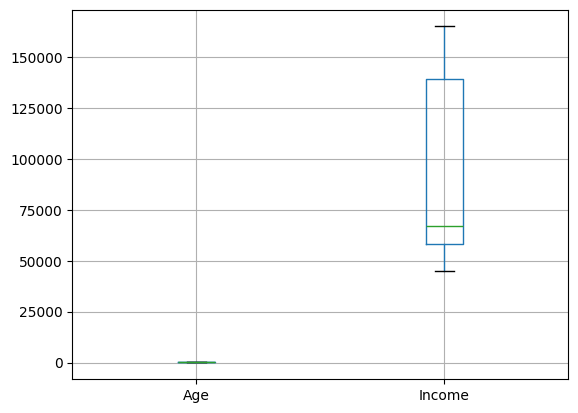

In [8]:
df.boxplot()

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>]], dtype=object)

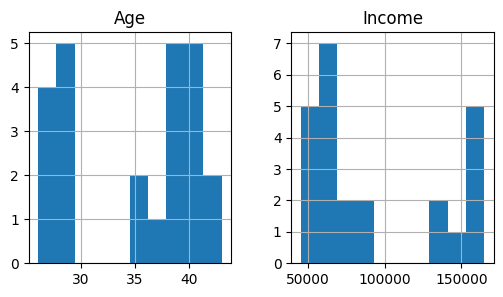

In [9]:
df.hist(figsize=(6,3))

In [10]:
X = df[['Age','Income']]
X[:2]

,Age,Income
0,27,70000
1,29,90000


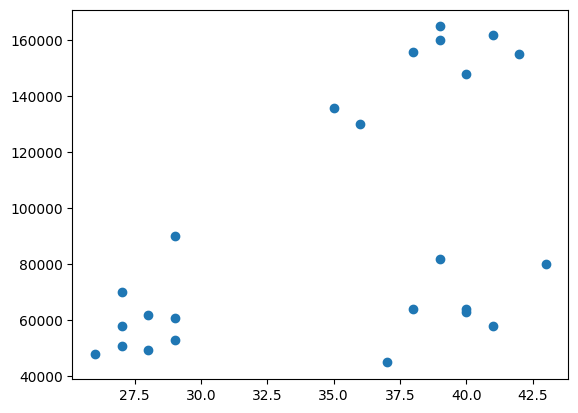

In [11]:
plt.scatter(X['Age'],X['Income'])

<Axes: xlabel='Age', ylabel='Income'>

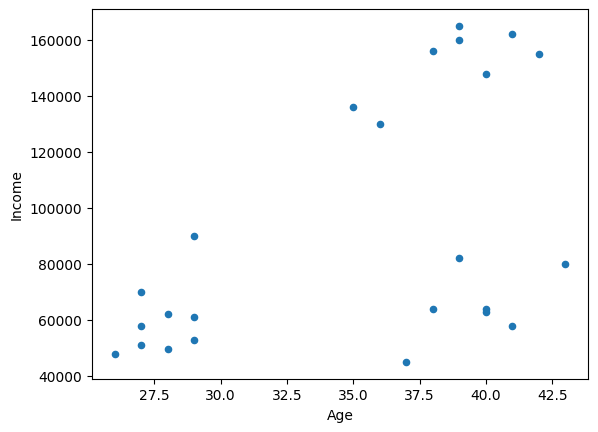

In [13]:
df.plot.scatter(x='Age',y='Income')  # pandas plotting

In [14]:
X.describe().T   # helps to check if theres noise/outliers

,count,mean,std,min,25%,50%,75%,max
Age,24.0,34.916667,5.933814,26.0,28.75,37.5,40.0,43.0
Income,24.0,92104.166667,44673.204489,45000.0,58000.00,67000.0,139000.0,165000.0


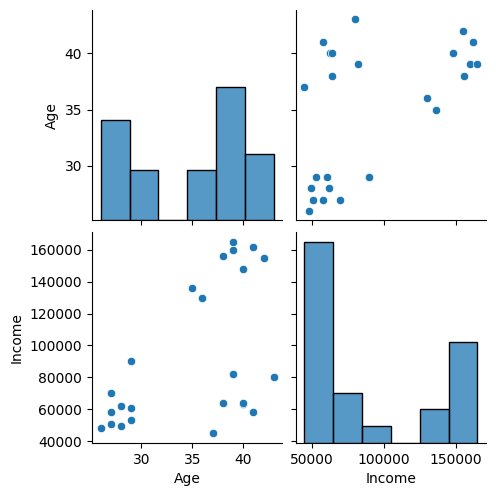

In [16]:
sns.pairplot(df)

# Finding k using K means

In [17]:
# default k means has 8 cluster
model = KMeans(n_clusters=3)

In [18]:
model

KMeans(n_clusters=3)

In [19]:
# training -  only x is used becoz unsupervised data has no output data
model.fit(X)

KMeans(n_clusters=3)

In [20]:
model.cluster_centers_[:,:]   # cluster centroids

array([[3.98333333e+01, 1.57666667e+05],
       [3.30000000e+01, 6.24062500e+04],
       [3.55000000e+01, 1.33000000e+05]])

In [21]:
X

,Age,Income
0,27,70000
1,29,90000
2,29,61000
3,28,62000
4,42,155000
5,39,160000
6,41,162000
7,38,156000
8,36,130000
9,35,136000


In [22]:
model.cluster_centers_[:,:-1]   # age,income

array([[39.83333333],
       [33.        ],
       [35.5       ]])

In [23]:
model.cluster_centers_[:,-1:]

array([[157666.66666667],
       [ 62406.25      ],
       [133000.        ]])

In [25]:
model.labels_    # it shows in which cluster the number is
# 0- cluster 1, 1- cluster 2,2- cluster 3

array([1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0], dtype=int32)

In [26]:
model.predict(X)  # test the clusters are predicted right

array([1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0], dtype=int32)

In [27]:
len(X)

24

In [28]:
model

KMeans(n_clusters=3)

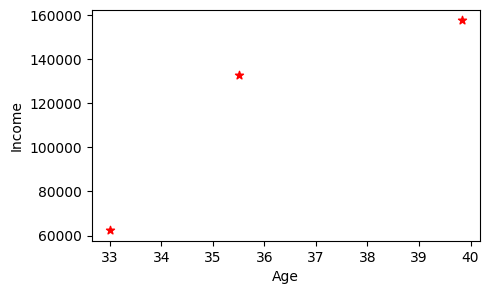

In [30]:
# ploting centroids
plt.figure(figsize=(5,3))
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [33]:
# testing phase = this will train and predict the model
# it directly gives the cluster numbers for all X values
model.fit_predict(X)

array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2,
       2, 1], dtype=int32)

In [34]:
# create a copy
x_new = X.copy()

In [36]:
x_new[:2]

,Age,Income
0,27,70000
1,29,90000


In [39]:
# adding cluster column in the data
X['cluster'] = model.fit_predict(X)
X[:3]

,Age,Income,cluster
0,27,70000,2
1,29,90000,0
2,29,61000,2


In [40]:
X.shape

(24, 3)

In [41]:
# create df for each cluster
df1 = X[X['cluster'] == 0]
df2 = X[X['cluster'] == 1]
df3 = X[X['cluster'] == 2]

In [42]:
df1

,Age,Income,cluster
1,29,90000,0
18,43,80000,0
19,39,82000,0


In [44]:
df3[:3]

,Age,Income,cluster
0,27,70000,2
2,29,61000,2
3,28,62000,2


In [45]:
df2[:3]

,Age,Income,cluster
4,42,155000,1
5,39,160000,1
6,41,162000,1


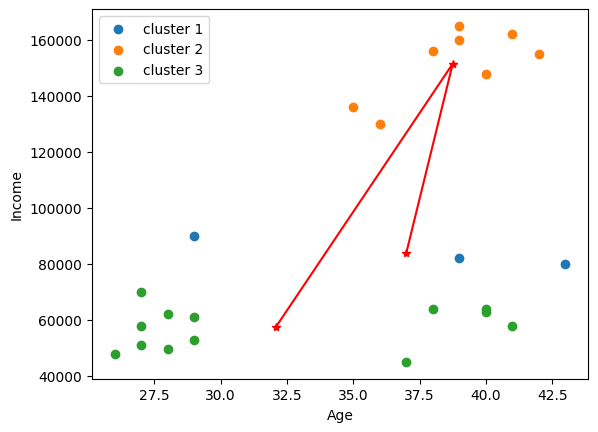

In [51]:
# ploting the data of df1,df2,df3 with the centroides
plt.scatter(df1['Age'],df1['Income'],label='cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='cluster 3')
plt.plot(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()   # to make visiblity of labels
plt.show()

- From above we can see that the clusters are not properly formed they are in the range of income
- So to reduce the dominance of income over age we will use feature scaling

In [52]:
scaler = MinMaxScaler()
# formula = X - min(x) / max(x)-min(x)

In [53]:
df['Income'] = scaler.fit_transform(df[['Income']])
df['Age'] = scaler.fit_transform(df[['Age']])

In [55]:
df.head()   # in between probablity of 0 to 1

,Name,Age,Income
0,Amit,0.058824,0.208333
1,Akash,0.176471,0.375000
2,Shriya,0.176471,0.133333
3,Anita,0.117647,0.141667
4,Sudhir,0.941176,0.916667


In [56]:
new_scale = MinMaxScaler()
# for both the columns it gives both ans together then we need to seperate it
# so better do it seperatly
new_scale.fit_transform(df[['Income','Age']])

array([[0.20833333, 0.05882353],
       [0.375     , 0.17647059],
       [0.13333333, 0.17647059],
       [0.14166667, 0.11764706],
       [0.91666667, 0.94117647],
       [0.95833333, 0.76470588],
       [0.975     , 0.88235294],
       [0.925     , 0.70588235],
       [0.70833333, 0.58823529],
       [0.75833333, 0.52941176],
       [0.        , 0.64705882],
       [0.025     , 0.        ],
       [0.05      , 0.05882353],
       [0.0375    , 0.11764706],
       [0.06666667, 0.17647059],
       [1.        , 0.76470588],
       [0.15      , 0.82352941],
       [0.15833333, 0.82352941],
       [0.29166667, 1.        ],
       [0.30833333, 0.76470588],
       [0.10833333, 0.88235294],
       [0.15833333, 0.70588235],
       [0.10833333, 0.05882353],
       [0.85833333, 0.82352941]])

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>]], dtype=object)

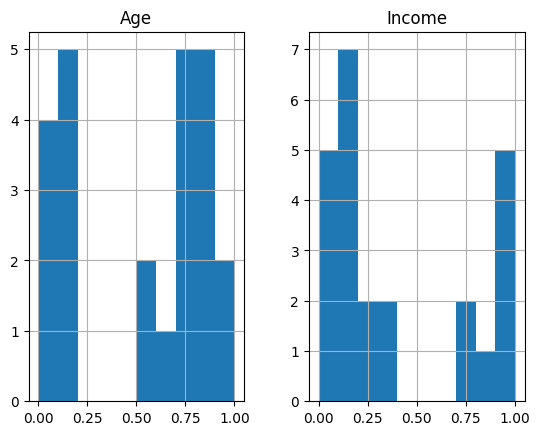

In [57]:
df.hist()

In [59]:
# now scaling is done create a new obj
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [62]:
y_pred = km.fit_predict(df[['Age','Income']])   # predicted clusters
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2,
       0, 1], dtype=int32)

In [63]:
km.labels_    # actual clusters

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2,
       0, 1], dtype=int32)

In [64]:
# lets add new column cluster in df
df['clusters'] = y_pred

In [65]:
df[:3]

,Name,Age,Income,clusters
0,Amit,0.058824,0.208333,0
1,Akash,0.176471,0.375000,0
2,Shriya,0.176471,0.133333,0


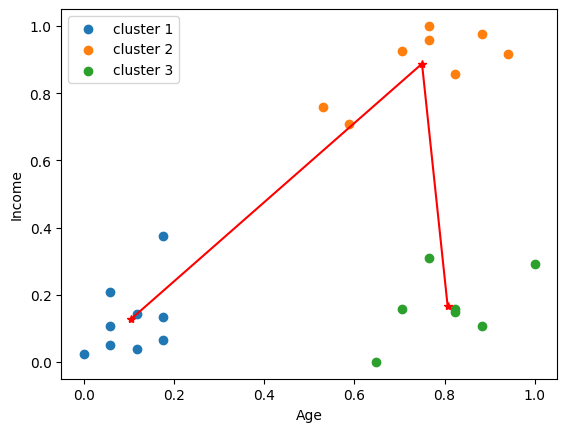

In [70]:
# ploting the data for each clusters with centroids
# seperating clusters
df1 = df[df['clusters']==0]
df2 = df[df['clusters']==1]
df3 = df[df['clusters']==2]
# ploting
plt.scatter(df1['Age'],df1['Income'],label='cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='cluster 3')
plt.plot(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

- Now the centroides of cluster present in center

- Its showing correctly positioned centroides